In [1]:
!pip install pytorch_gan_metrics

# Import Lib

In [1]:
import time
import cv2
import os
import re

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
import tensorflow as tf
from keras import layers
from tensorflow.keras.utils import img_to_array
from sklearn.model_selection import train_test_split
import matplotlib.colors as mcolors

# Config

In [2]:
class config:
    face_train_path = r"E:\SketchToFace\ProcessedImages\train\real"
    face_test_path = r"E:\SketchToFace\ProcessedImages\test\real"
    sketch_train_path = r"E:\SketchToFace\ProcessedImages\train\sketches"
    sketch_test_path = r"E:\SketchToFace\ProcessedImages\test\sketches"
    SIZE = 256
    SEED = 42
    EPOCHS = 250
    LR = 2e-4
    LAMBDA = 100
    TRAIN_BATCH_SIZE = 8
    TEST_BATCH_SIZE = 8
    NUM_WORKERS = os.cpu_count()

# Setup for Training

In [4]:
def load_images(path):
    images = []
    file_names = []
    files = os.listdir(path)
    files = sorted_alphanumeric(files)
    
    for file_name in tqdm(files):
        file_path = os.path.join(path, file_name)
        # Check if file exists
        if not os.path.exists(file_path):
            print(f"Warning: File not found - {file_path}")
            continue
            
        img = cv2.imread(file_path, 1)
        # Check if image was loaded successfully
        if img is None:
            print(f"Warning: Failed to load image - {file_path}")
            continue
            
        try:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (config.SIZE, config.SIZE))
            img = img.astype('float32') / 255.0
            images.append(img_to_array(img))
            file_names.append(file_path)
        except Exception as e:
            print(f"Error processing {file_path}: {str(e)}")
            continue
    
    if not images:
        raise ValueError(f"No valid images found in directory: {path}")
        
    return images, file_names

def sorted_alphanumeric(data):  
    convert = lambda text: int(text) if text.isdigit() else text.lower()
    alphanum_key = lambda key: [convert(c) for c in re.split('([0-9]+)', key)]
    return sorted(data, key=alphanum_key)



In [5]:
def load_images(path):
    images = []
    file_names = []
    files = os.listdir(path)
    files = sorted_alphanumeric(files)
    
    print(f"\nLoading images from: {path}")
    
    for file_name in tqdm(files):
        file_path = os.path.join(path, file_name)
        
        # Detailed file checks
        if not os.path.exists(file_path):
            print(f"Warning: File not found - {file_path}")
            continue
            
        if os.path.getsize(file_path) == 0:
            print(f"Warning: Empty file - {file_path}")
            continue
            
        img = cv2.imread(file_path, 1)
        if img is None:
            print(f"Warning: Failed to load image - {file_path}")
            print(f"File size: {os.path.getsize(file_path)} bytes")
            print(f"File permissions: {oct(os.stat(file_path).st_mode)[-3:]}")
            continue
        
        try:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (config.SIZE, config.SIZE))
            img = img.astype('float32') / 255.0
            images.append(img_to_array(img))
            file_names.append(file_path)
        except Exception as e:
            print(f"Error processing {file_path}: {str(e)}")
            print(f"Image shape: {img.shape if img is not None else 'None'}")
            continue
    
    if not images:
        raise ValueError(f"No valid images found in directory: {path}")
    
    print(f"Successfully loaded {len(images)} images")
    return images, file_names
face_train, face_train_path = load_images(config.face_train_path)
face_test, face_test_path = load_images(config.face_test_path)
sketch_train, sketch_train_path = load_images(config.sketch_train_path)
sketch_test, sketch_test_path = load_images(config.sketch_test_path)


Loading images from: E:\SketchToFace\ProcessedImages\train\real


100%|██████████| 2790/2790 [00:06<00:00, 446.47it/s]


Successfully loaded 2790 images

Loading images from: E:\SketchToFace\ProcessedImages\test\real


100%|██████████| 600/600 [00:01<00:00, 399.75it/s]


Successfully loaded 600 images

Loading images from: E:\SketchToFace\ProcessedImages\train\sketches


100%|██████████| 2790/2790 [00:06<00:00, 448.10it/s]


Successfully loaded 2790 images

Loading images from: E:\SketchToFace\ProcessedImages\test\sketches


100%|██████████| 600/600 [00:01<00:00, 388.33it/s]

File size: 21886 bytes
File permissions: 666
Successfully loaded 599 images


In [6]:
def create_dataset(image_paths, batch_size):
    """Creates a dataset that loads images on-the-fly instead of all at once"""
    def load_and_preprocess(path):
        # Convert string tensor to string
        path = path.numpy().decode('utf-8')
        # Load image
        img = cv2.imread(path, 1)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (config.SIZE, config.SIZE))
        img = img.astype('float32') / 255.0
        return img

    # Wrap the python function to make it compatible with TensorFlow
    def tf_load_and_preprocess(path):
        return tf.py_function(load_and_preprocess, [path], tf.float32)

    # Create dataset from paths
    dataset = tf.data.Dataset.from_tensor_slices(image_paths)
    
    # Apply transformations
    dataset = dataset.map(tf_load_and_preprocess, 
                         num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Create datasets
face_train_dataset = create_dataset(face_train_path, config.TRAIN_BATCH_SIZE)
sketch_train_dataset = create_dataset(sketch_train_path, config.TRAIN_BATCH_SIZE)
face_test_dataset = create_dataset(face_test_path, config.TEST_BATCH_SIZE)
sketch_test_dataset = create_dataset(sketch_test_path, config.TEST_BATCH_SIZE)

# Create path datasets (if you still need them)
face_path_train_dataset = tf.data.Dataset.from_tensor_slices(face_train_path).batch(config.TRAIN_BATCH_SIZE)
sketch_path_train_dataset = tf.data.Dataset.from_tensor_slices(sketch_train_path).batch(config.TRAIN_BATCH_SIZE)
face_path_test_dataset = tf.data.Dataset.from_tensor_slices(face_test_path).batch(config.TEST_BATCH_SIZE)
sketch_path_test_dataset = tf.data.Dataset.from_tensor_slices(sketch_test_path).batch(config.TEST_BATCH_SIZE)

In [ ]:
# face_train_dataset = tf.data.Dataset.from_tensor_slices(np.array(face_train)).batch(config.TRAIN_BATCH_SIZE)
# sketch_train_dataset = tf.data.Dataset.from_tensor_slices(np.array(sketch_train)).batch(config.TRAIN_BATCH_SIZE)

# face_test_dataset = tf.data.Dataset.from_tensor_slices(np.array(face_test)).batch(config.TEST_BATCH_SIZE)
# sketch_test_dataset = tf.data.Dataset.from_tensor_slices(np.array(sketch_test)).batch(config.TEST_BATCH_SIZE)

# face_path_train_dataset = tf.data.Dataset.from_tensor_slices(np.array(face_train_path)).batch(config.TRAIN_BATCH_SIZE)
# sketch_path_train_dataset = tf.data.Dataset.from_tensor_slices(np.array(sketch_train_path)).batch(config.TRAIN_BATCH_SIZE)

# face_path_test_dataset = tf.data.Dataset.from_tensor_slices(np.array(face_test_path)).batch(config.TEST_BATCH_SIZE)
# sketch_path_test_dataset = tf.data.Dataset.from_tensor_slices(np.array(sketch_test_path)).batch(config.TEST_BATCH_SIZE)

: 

In [7]:
example_face = next(iter(face_train_dataset))
example_sketch = next(iter(sketch_train_dataset))

In [8]:
def plot_images(a = 1):
    for i in range(a):
        plt.figure(figsize = (10,10))
        plt.subplot(121)
        plt.title('color')
        plt.imshow(example_face[i] )

        plt.subplot(122)
        plt.title('gray')
        plt.imshow(example_sketch[i])
        plt.show()

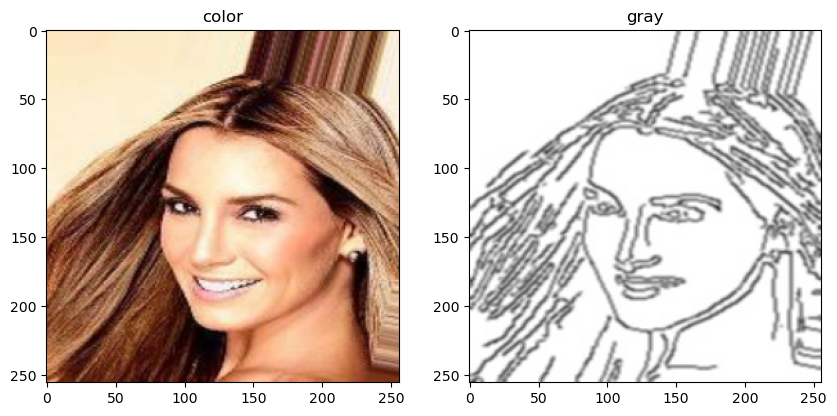

In [9]:
plot_images(1)

## Downsample & Upsample

In [10]:
def downsample(filters, size, apply_batchnorm=True):
    result = tf.keras.Sequential()
    result.add(tf.keras.layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer='he_normal', use_bias=False))

    if apply_batchnorm:
        result.add(tf.keras.layers.BatchNormalization())

    result.add(tf.keras.layers.LeakyReLU())

    return result

def upsample(filters, size, apply_dropout=False):

    result = tf.keras.Sequential()
    result.add(tf.keras.layers.Conv2DTranspose(filters, size, strides=2,
                                                padding='same',
                                                kernel_initializer='he_normal',
                                                use_bias=False))

    result.add(tf.keras.layers.BatchNormalization())

    if apply_dropout:
        result.add(tf.keras.layers.Dropout(0.5))

    result.add(tf.keras.layers.ReLU())

    return result  

## Generator

In [11]:
def Generator():
    inputs = tf.keras.layers.Input(shape=[256,256,3])

    down_stack = [
        downsample(64, 4, apply_batchnorm=False), # (bs, 128, 128, 64)
        downsample(128, 4), # (bs, 64, 64, 128)
        downsample(256, 4), # (bs, 32, 32, 256)
        downsample(512, 4), # (bs, 16, 16, 512)
        downsample(512, 4), # (bs, 8, 8, 512)
        downsample(512, 4), # (bs, 4, 4, 512)
        downsample(512, 4), # (bs, 2, 2, 512)
        downsample(512, 4), # (bs, 1, 1, 512)
    ]

    up_stack = [
        upsample(512, 4, apply_dropout=True), # (bs, 2, 2, 1024)
        upsample(512, 4, apply_dropout=True), # (bs, 4, 4, 1024)
        upsample(512, 4, apply_dropout=True), # (bs, 8, 8, 1024)
        upsample(512, 4), # (bs, 16, 16, 1024)
        upsample(256, 4), # (bs, 32, 32, 512)
        upsample(128, 4), # (bs, 64, 64, 256)
        upsample(64, 4), # (bs, 128, 128, 128)
    ]

    initializer = tf.random_normal_initializer(0., 0.02)
    last = tf.keras.layers.Conv2DTranspose(3, 4,
                                         strides=2,
                                         padding='same',
                                         kernel_initializer=initializer,
                                         activation='tanh') # (bs, 256, 256, 3)

    x = inputs

    # Downsampling through the model
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)

    skips = reversed(skips[:-1])

    # Upsampling and establishing the skip connections
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = tf.keras.layers.Concatenate()([x, skip])

    x = last(x)

    return tf.keras.Model(inputs=inputs, outputs=x)

## Discriminator

In [12]:
def Discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)

    inp = tf.keras.layers.Input(shape=[256, 256, 3], name='input_image')
    tar = tf.keras.layers.Input(shape=[256, 256, 3], name='target_image')

    x = tf.keras.layers.concatenate([inp, tar]) # (bs, 256, 256, channels*2)

    down1 = downsample(64, 4, False)(x) # (bs, 128, 128, 64)
    down2 = downsample(128, 4)(down1) # (bs, 64, 64, 128)
    down3 = downsample(256, 4)(down2) # (bs, 32, 32, 256)

    zero_pad1 = tf.keras.layers.ZeroPadding2D()(down3) # (bs, 34, 34, 256)
    conv = tf.keras.layers.Conv2D(512, 4, strides=1,
                                kernel_initializer=initializer,
                                use_bias=False)(zero_pad1) # (bs, 31, 31, 512)

    batchnorm1 = tf.keras.layers.BatchNormalization()(conv)

    leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm1)

    zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky_relu) # (bs, 33, 33, 512)

    last = tf.keras.layers.Conv2D(1, 4, strides=1,
                                kernel_initializer=initializer)(zero_pad2) # (bs, 30, 30, 1)

    return tf.keras.Model(inputs=[inp, tar], outputs=last)

In [13]:
generator = Generator()
generator.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 sequential (Sequential)        (None, 128, 128, 64  3072        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 sequential_1 (Sequential)      (None, 64, 64, 128)  131584      ['sequential[0][0]']             
                                                                                              

In [14]:
discriminator = Discriminator()
discriminator.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_image (InputLayer)       [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 target_image (InputLayer)      [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 concatenate_7 (Concatenate)    (None, 256, 256, 6)  0           ['input_image[0][0]',            
                                                                  'target_image[0][0]']     

In [15]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)
generator_optimizer = tf.keras.optimizers.Adam(config.LR, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(config.LR, beta_1=0.5)

LAMBDA = config.LAMBDA

def generator_loss(disc_generated_output, gen_output, target):
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)

    # mean absolute error
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))

    total_gen_loss = gan_loss + (LAMBDA * l1_loss)

    return total_gen_loss, gan_loss, l1_loss

def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)

    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)

    total_disc_loss = real_loss + generated_loss

    return total_disc_loss

In [16]:
def train_step(input_image, target, epoch):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = generator(input_image, training=True)

        disc_real_output = discriminator([input_image, target], training=True)
        disc_generated_output = discriminator([input_image, gen_output], training=True)

        gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(disc_generated_output, gen_output, target)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

    generator_gradients = gen_tape.gradient(gen_total_loss, generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables))
    
    # Calculate SSIM and PSNR
    ssim = tf.image.ssim(target, gen_output, max_val=1.0)
    psnr = tf.image.psnr(target, gen_output, max_val=1.0)
    
    # Return loss and metrics
    return tf.get_static_value(gen_total_loss), tf.get_static_value(disc_loss), tf.reduce_mean(ssim).numpy(), tf.reduce_mean(psnr).numpy()

def validate_step(input_image, target):
    gen_output = generator(input_image, training=False)

    # Calculate SSIM and PSNR
    ssim = tf.image.ssim(target, gen_output, max_val=1.0)
    psnr = tf.image.psnr(target, gen_output, max_val=1.0)
    
    # Return loss and metrics
    return tf.reduce_mean(ssim).numpy(), tf.reduce_mean(psnr).numpy()

def fit(train_ds, val_ds, epochs):
    gen_losses = []
    disc_losses = []
    val_ssims = []
    val_psnrs = []
    train_ssims = []
    train_psnrs = []

    for epoch in range(epochs):
        start = time.time()
        epoch_gen_loss = []
        epoch_disc_loss = []
        
        # Train
        train_ssim = 0
        train_psnr = 0
        train_steps = 0
        
        for n, (input_image, target) in train_ds.enumerate():
            gen_total_loss, disc_loss, ssim, psnr = train_step(input_image, target, epoch)
            epoch_gen_loss.append(gen_total_loss)
            epoch_disc_loss.append(disc_loss)
            train_ssim += ssim
            train_psnr += psnr
            train_steps += 1
            
        train_ssim /= train_steps
        train_psnr /= train_steps

        train_ssims.append(train_ssim)
        train_psnrs.append(train_psnr) 
        
        gen_losses.append(tf.reduce_mean(epoch_gen_loss))
        disc_losses.append(tf.reduce_mean(epoch_disc_loss))
        
        print(f"Epoch: {epoch+1} || G_Loss: {gen_losses[-1]:.2f} || D_Loss: {disc_losses[-1]:.2f} || Time: {time.time()-start:.2f} sec/epoch")
        print(f"Training - SSIM: {train_ssim:.2f} || PSNR: {train_psnr:.2f}")
        
        # Validate
        val_ssim = 0
        val_psnr = 0
        val_steps = 0
        
        for n, (input_image, target) in val_ds.enumerate():
            ssim, psnr = validate_step(input_image, target)
            val_ssim += ssim
            val_psnr += psnr
            val_steps += 1

        val_ssim /= val_steps
        val_psnr /= val_steps

        val_ssims.append(val_ssim)
        val_psnrs.append(val_psnr)

        print(f"Validation - SSIM: {val_ssim:.2f} || PSNR: {val_psnr:.2f}\n")

    # Plot losses
    plt.plot(range(1, epochs + 1), gen_losses, label='Generator Loss')
    plt.plot(range(1, epochs + 1), disc_losses, label='Discriminator Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Generator and Discriminator Loss')
    plt.legend()
    plt.show()
    
    # Plot metrics
    plt.plot(range(1, epochs + 1), train_ssims, label='Training SSIM')
    plt.plot(range(1, epochs + 1), train_psnrs, label='Training PSNR')
    plt.xlabel('Epoch')
    plt.ylabel('Metrics')
    plt.title('Training Metrics')
    plt.legend()
    plt.show()
    
    # Plot metrics
    plt.plot(range(1, epochs + 1), val_ssims, label='Validation SSIM')
    plt.plot(range(1, epochs + 1), val_psnrs, label='Validation PSNR')
    plt.xlabel('Epoch')
    plt.ylabel('Metrics')
    plt.title('Validation Metrics')
    plt.legend()
    plt.show()

# Training

In [17]:
fit(tf.data.Dataset.zip((sketch_train_dataset, face_train_dataset)), tf.data.Dataset.zip((sketch_test_dataset, face_test_dataset)), epochs=config.EPOCHS)

Epoch: 1 || G_Loss: 25.92 || D_Loss: 0.83 || Time: 172.96 sec/epoch
Training - SSIM: 0.21 || PSNR: 10.50


ValueError: Two images are not compatible: (8, 256, 256, 3) and (7, 256, 256, 3)

In [17]:
generator.save('generator_final.h5')

In [18]:
# generator = tf.keras.models.load_model('generator_final.h5')

### Generate and export files

In [19]:
train_dir = "/kaggle/working/generate_img/train"
val_dir = "/kaggle/working/generate_img/val"
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

In [20]:
def generate_images(model, image_input, tar, path, mode, show):
    prediction = model(image_input, training=True)  # Ảnh generate từ input
    
    if mode =='train':
        display_list = [image_input[0], tar[0], prediction[0]]
        title = ['Input Image', 'Ground Truth', 'Predicted Image']
        if show == True:
            plt.figure(figsize=(15, 15))
            for i in range(3):
                plt.subplot(1, 3, i+1)
                plt.title(title[i])
                # getting the pixel values between [0, 1] to plot it.
                plt.imshow(display_list[i])
                plt.axis('off')
            plt.show()
        
        for i in range(len(image_input)):
            filename = path[i].numpy().decode("utf-8").split("/")[-1]
            prediction_np = prediction[i].numpy()
            prediction_np = mcolors.Normalize()(prediction_np)
            prediction_path = os.path.join("/kaggle/working/generate_img/train", filename)
            plt.imsave(prediction_path, prediction_np)
        
    elif mode == 'val':
        display_list = [image_input[0], tar[0], prediction[0]]
        title = ['Input Image', 'Ground Truth', 'Predicted Image']
        if show == True:
            plt.figure(figsize=(15, 15))
            for i in range(3):
                plt.subplot(1, 3, i+1)
                plt.title(title[i])
                # getting the pixel values between [0, 1] to plot it.
                plt.imshow(display_list[i])
                plt.axis('off')
            plt.show()
        
        for i in range(len(image_input)):
            filename = path[i].numpy().decode("utf-8").split("/")[-1]
            prediction_np = prediction[i].numpy()
            prediction_np = mcolors.Normalize()(prediction_np)
            prediction_path = os.path.join("/kaggle/working/generate_img/val", filename)
            plt.imsave(prediction_path, prediction_np)
            
    elif mode == 'test':
        display_list = [image_input[0], prediction[0]]
        title = ['Input Image', 'Predicted Image']
        
        for i in range(2):
            plt.figure(figsize=(15, 15))
            plt.subplot(1, 2, i+1)
            plt.title(title[i])
            plt.imshow(display_list[i])
            plt.axis('off')
        plt.show()
        
# for example_input, example_target, path in tf.data.Dataset.zip((sketch_train_dataset, face_train_dataset, face_path_train_dataset)).take(5):
#     generate_images(generator, example_input, example_target, path, mode='train', show=True)

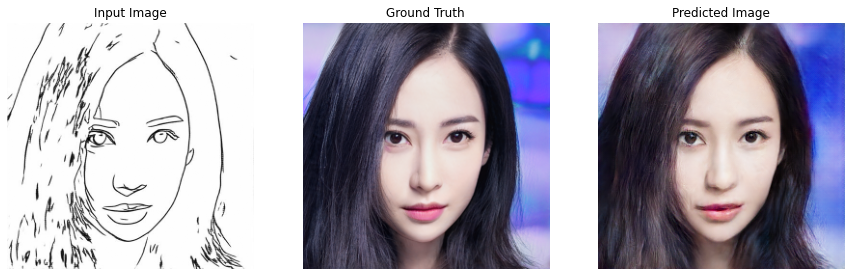

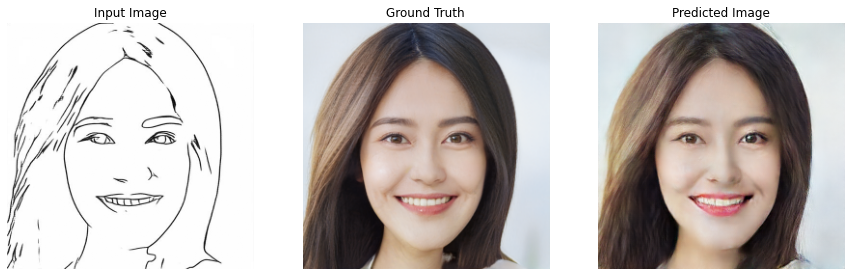

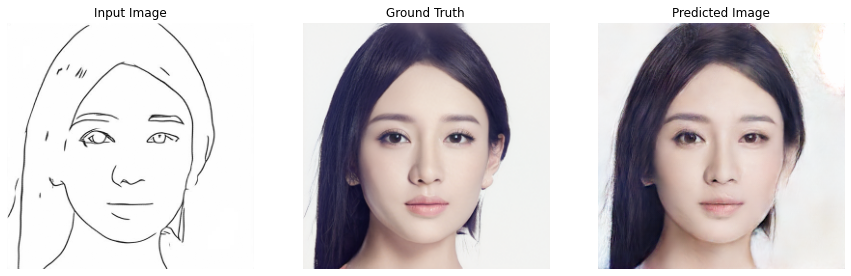

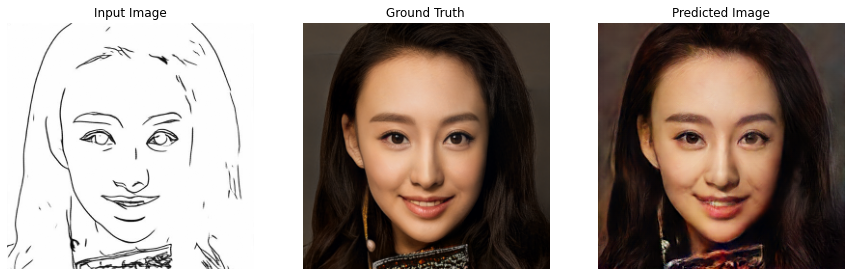

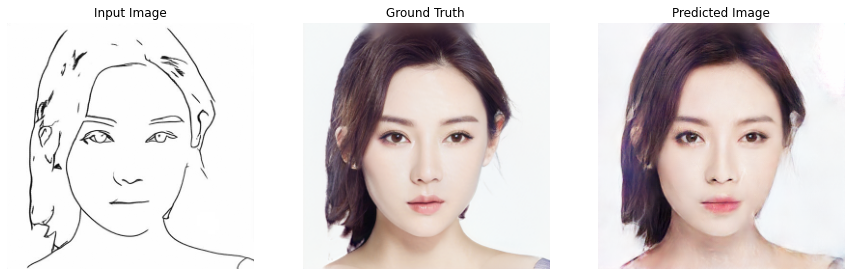

In [21]:
for example_input, example_target, path in tf.data.Dataset.zip((sketch_train_dataset, face_train_dataset, face_path_train_dataset)).take(5):
    generate_images(generator, example_input, example_target, path, mode='train', show=True)

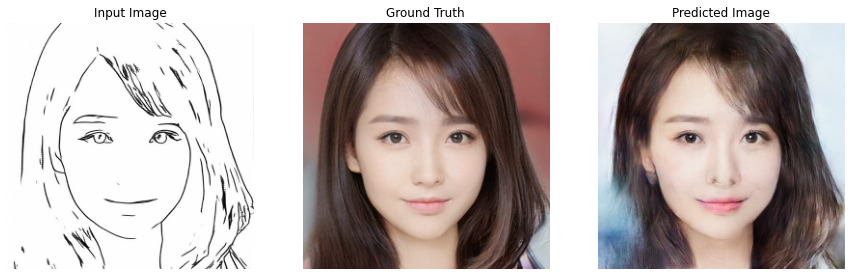

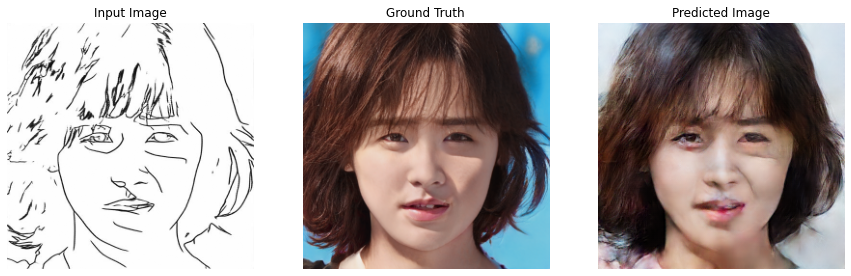

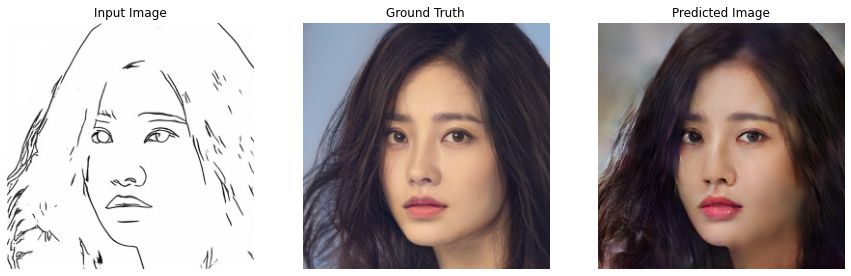

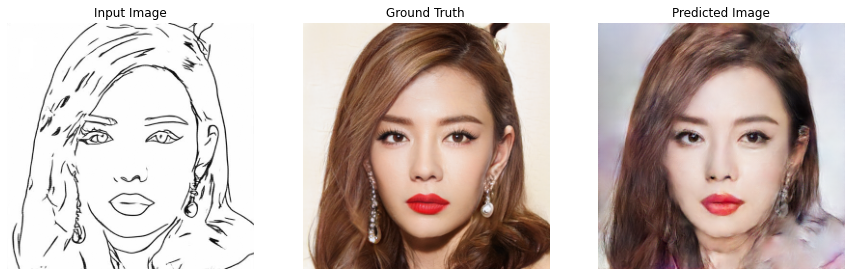

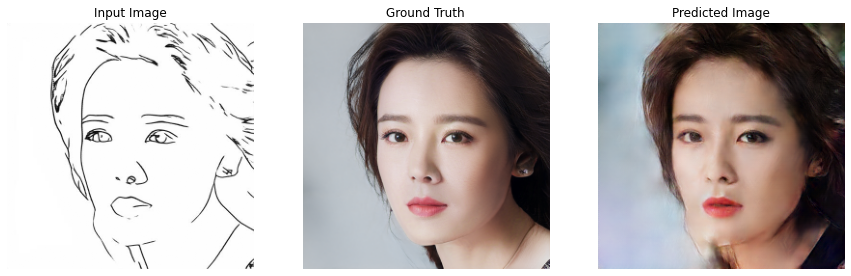

In [22]:
for example_input, example_target, path in tf.data.Dataset.zip((sketch_test_dataset, face_test_dataset, face_path_test_dataset)).take(5):
    generate_images(generator, example_input, example_target, path, mode='val', show=True)

### Testing

In [23]:
test_path = '/kaggle/input/test-gan'
test_img, _ = load_images(test_path)
test_dataset_t = tf.data.Dataset.from_tensor_slices(np.array(test_img)).batch(1)

100%|██████████| 7/7 [00:00<00:00, 46.31it/s]


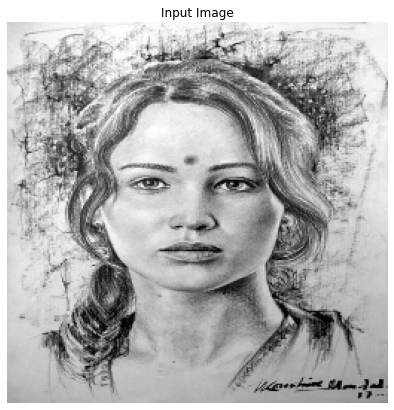

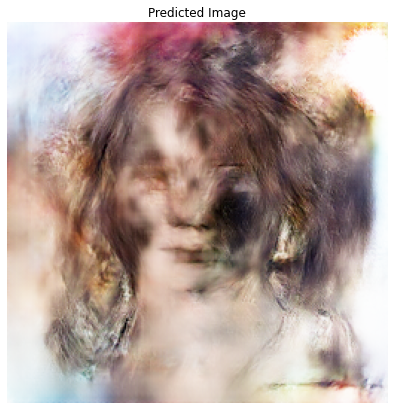

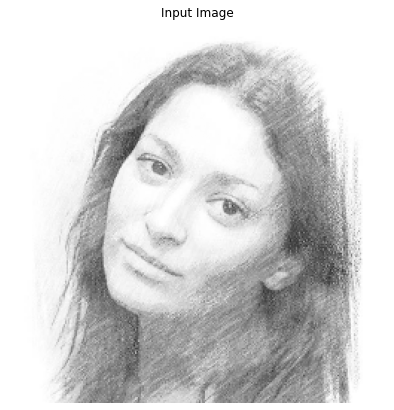

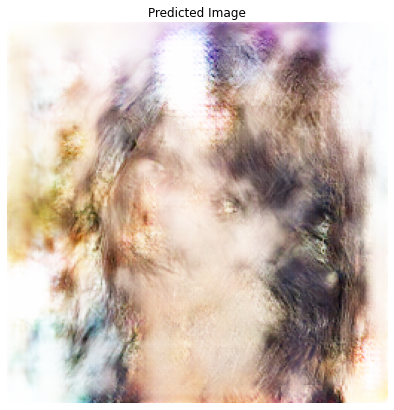

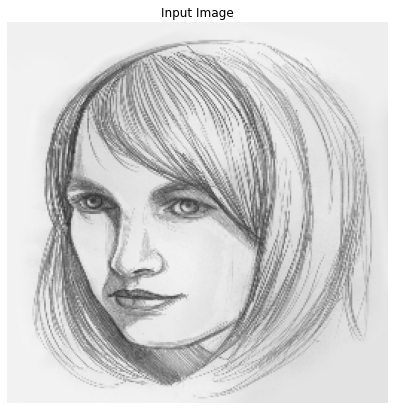

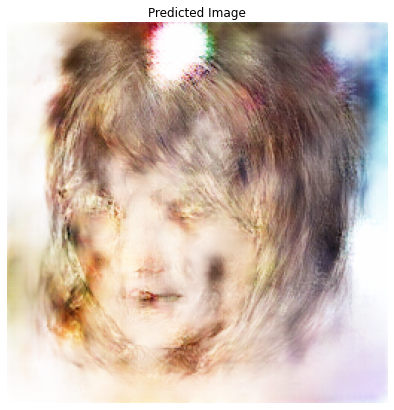

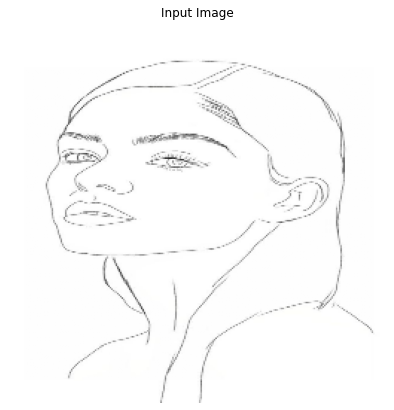

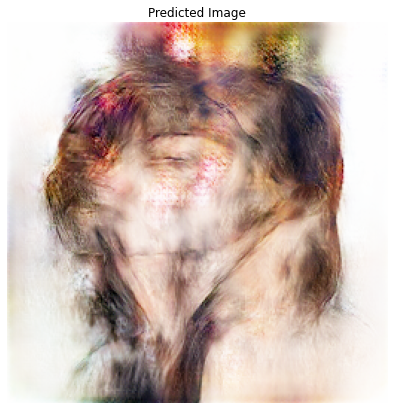

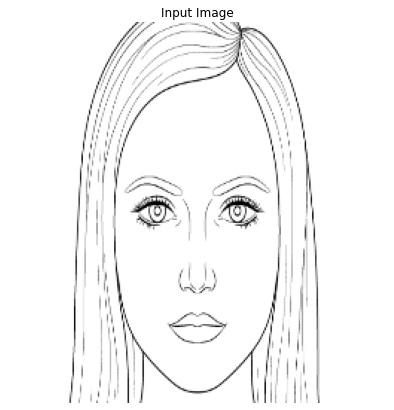

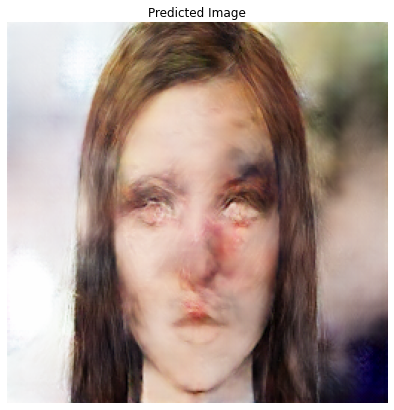

In [24]:
for ex_input, ex_target in tf.data.Dataset.zip((test_dataset_t, test_dataset_t)).take(5):
    generate_images(generator, ex_input, ex_target, _, mode='test', show=True)

In [25]:
# from pytorch_gan_metrics import get_inception_score_from_directory
# IS, IS_std = get_inception_score_from_directory("/kaggle/input/output-8b-300p-pix2pix/generate_img/val")
# IS, IS_std

In [26]:
# IS, IS_std = get_inception_score_from_directory("/kaggle/input/output-8b-300p-pix2pix/generate_img/train")
# IS, IS_std